# Observable-only boosted trees for $N_{\mathrm{part}}$ and $b$

This notebook predicts generator labels $N_{\mathrm{part}}$ and impact parameter
$b$ from measurable final-state particle summaries. Neither target, event ID,
the ROOT `mul` branch, nor any Glauber geometry quantity is included in the
feature matrix.

The RefMult3 baseline is calibrated with a two-component Glauber+negative-
binomial model. RefMult3 is defined here as charged final-state particles with
$p_T \geq 0.15$ GeV/$c$ and $|\eta|<1$, excluding protons and antiprotons.

In [1]:
from pathlib import Path
import sys
import time

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import uproot
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
rng = np.random.default_rng(SEED)

search_roots = (Path.cwd(), *Path.cwd().parents)
PROJECT_ROOT = next(
    (root for root in search_roots if (root / "Glauber/nuclei.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the Deep_Learning_Npart project root.")

DATA_ROOT = PROJECT_ROOT / "UrQMD_C_Code/Data"
CACHE_FILE = PROJECT_ROOT / "Data/processed/urqmd_observable_features.npz"
RESULTS_DIR = PROJECT_ROOT / "results/boosted_tree"
GLAUBER_DIR = PROJECT_ROOT / "Glauber/glauber_output"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE.parent.mkdir(parents=True, exist_ok=True)

glauber_module_dir = str(PROJECT_ROOT / "Glauber")
if glauber_module_dir not in sys.path:
    sys.path.insert(0, glauber_module_dir)
import nbd_fitting as nbd

print("Project root:", PROJECT_ROOT)

Project root: /workspace/research/Deep_Learning_Npart


## Build observable event features

The ROOT files are processed in chunks. Only particle IDs and momenta enter the
features. The generator `Npart` and `b` branches are copied separately as
supervised labels.

In [2]:
FEATURE_NAMES = np.array([
    "refmult3",
    "n_charged_eta1",
    "n_charged_eta16",
    "n_forward_charged",
    "n_pi_plus",
    "n_pi_minus",
    "n_k_plus",
    "n_k_minus",
    "n_proton",
    "n_antiproton",
    "sum_pt",
    "mean_pt",
    "std_pt",
    "mean_abs_eta",
    "std_eta",
    "net_charge",
    "q2_magnitude",
])

# Absolute PDG IDs of charged species expected in the UrQMD final state.
CHARGED_ABS_PDG = (
    11, 13, 211, 321, 2212, 3112, 3222, 3312, 3334,
    1114, 2114, 2214, 2224, 3114, 3214, 3224, 3314, 3324,
    1000010020, 1000010030, 1000020030, 1000020040,
)


def filled_stat(values, operation):
    result = operation(values, axis=1, mask_identity=True)
    return np.asarray(ak.to_numpy(ak.fill_none(result, 0.0)), dtype=np.float32)


def build_feature_archive(root_files, output_file):
    feature_blocks, npart_blocks, b_blocks = [], [], []
    started = time.time()
    for file_number, root_file in enumerate(root_files, start=1):
        source = f"{root_file}:urqmd"
        for arrays in uproot.iterate(
            source,
            ["pid", "px", "py", "pz", "Npart", "b"],
            step_size="30 MB",
            library="ak",
        ):
            pid = arrays["pid"]
            abs_pid = abs(pid)
            px, py, pz = arrays["px"], arrays["py"], arrays["pz"]
            pt = np.sqrt(px * px + py * py)
            safe_pt = ak.where(pt > 0, pt, 1.0)
            eta = np.arcsinh(pz / safe_pt)
            abs_eta = abs(eta)
            phi = np.arctan2(py, px)

            charged = abs_pid == CHARGED_ABS_PDG[0]
            for pdg_id in CHARGED_ABS_PDG[1:]:
                charged = charged | (abs_pid == pdg_id)

            track = charged & (pt >= 0.15) & np.isfinite(eta)
            eta1 = track & (abs_eta < 1.0)
            eta16 = track & (abs_eta < 1.6)
            forward = track & (abs_eta >= 1.0) & (abs_eta < 1.6)
            refmult3_mask = eta1 & (abs_pid != 2212)

            n_charged_eta1 = np.asarray(ak.to_numpy(ak.sum(eta1, axis=1)))
            n_charged_eta16 = np.asarray(ak.to_numpy(ak.sum(eta16, axis=1)))
            accepted_pt = pt[eta16]
            accepted_abs_eta = abs_eta[eta16]
            q_sign = ak.where(
                (abs_pid == 11) | (abs_pid == 13),
                -np.sign(pid),
                np.sign(pid),
            )
            q2x = filled_stat(np.cos(2.0 * phi)[eta16], ak.sum)
            q2y = filled_stat(np.sin(2.0 * phi)[eta16], ak.sum)
            q2 = np.sqrt(q2x * q2x + q2y * q2y) / np.sqrt(
                np.maximum(n_charged_eta16, 1)
            )

            columns = [
                ak.sum(refmult3_mask, axis=1),
                n_charged_eta1,
                n_charged_eta16,
                ak.sum(forward, axis=1),
                ak.sum(eta1 & (pid == 211), axis=1),
                ak.sum(eta1 & (pid == -211), axis=1),
                ak.sum(eta1 & (pid == 321), axis=1),
                ak.sum(eta1 & (pid == -321), axis=1),
                ak.sum(eta1 & (pid == 2212), axis=1),
                ak.sum(eta1 & (pid == -2212), axis=1),
                filled_stat(accepted_pt, ak.sum),
                filled_stat(accepted_pt, ak.mean),
                filled_stat(accepted_pt, ak.std),
                filled_stat(accepted_abs_eta, ak.mean),
                filled_stat(accepted_abs_eta, ak.std),
                filled_stat(q_sign[eta16], ak.sum),
                q2,
            ]
            block = np.column_stack(
                [np.asarray(col, dtype=np.float32) for col in columns]
            )
            feature_blocks.append(block)
            npart_blocks.append(
                np.asarray(ak.to_numpy(arrays["Npart"]), dtype=np.float32)
            )
            b_blocks.append(np.asarray(ak.to_numpy(arrays["b"]), dtype=np.float32))

        if file_number % 4 == 0 or file_number == len(root_files):
            print(f"Processed {file_number}/{len(root_files)} ROOT files")

    X = np.concatenate(feature_blocks)
    npart = np.concatenate(npart_blocks)
    b = np.concatenate(b_blocks)
    event_id = np.arange(len(X), dtype=np.int64)
    np.savez_compressed(
        output_file,
        X=X,
        feature_names=FEATURE_NAMES,
        Npart=npart,
        b=b,
        event_id=event_id,
    )
    print(f"Built {len(X):,} events in {time.time() - started:.1f} s")
    return X, npart, b, event_id


root_files = sorted(DATA_ROOT.glob("urqmd_*_run/Event_*.root"))
if not root_files:
    raise FileNotFoundError(f"No UrQMD ROOT files found below {DATA_ROOT}")

if CACHE_FILE.is_file():
    with np.load(CACHE_FILE, allow_pickle=False) as data:
        X = data["X"].copy()
        feature_names = data["feature_names"].astype(str)
        npart = data["Npart"].copy()
        impact_parameter = data["b"].copy()
        event_id = data["event_id"].copy()
    print(f"Loaded {len(X):,} cached events from {CACHE_FILE}")
else:
    X, npart, impact_parameter, event_id = build_feature_archive(
        root_files, CACHE_FILE
    )
    feature_names = FEATURE_NAMES.copy()

print("Feature matrix:", X.shape)
print("Features:", ", ".join(feature_names))

Loaded 200,000 cached events from /workspace/research/Deep_Learning_Npart/Data/processed/urqmd_observable_features.npz
Feature matrix: (200000, 17)
Features: refmult3, n_charged_eta1, n_charged_eta16, n_forward_charged, n_pi_plus, n_pi_minus, n_k_plus, n_k_minus, n_proton, n_antiproton, sum_pt, mean_pt, std_pt, mean_abs_eta, std_eta, net_charge, q2_magnitude


## Leakage checks and observable trigger

The analysis keeps events with RefMult3 greater than zero, an observable trigger
condition. Hidden labels are used only after the feature matrix has been frozen.

In [3]:
for forbidden in ("Npart", "b", "impact_parameter", "event_id", "Ncoll", "mul"):
    assert forbidden not in feature_names

refmult3_col = int(np.flatnonzero(feature_names == "refmult3")[0])
refmult3 = X[:, refmult3_col].astype(np.int32)
observable_mask = (
    (refmult3 > 0)
    & np.all(np.isfinite(X), axis=1)
    & np.isfinite(npart)
    & np.isfinite(impact_parameter)
)

X_selected = X[observable_mask]
npart_selected = npart[observable_mask]
b_selected = impact_parameter[observable_mask]
refmult3_selected = refmult3[observable_mask]
event_id_selected = event_id[observable_mask]

print(f"Observable-trigger sample: {len(X_selected):,} / {len(X):,} events")
print(
    f"Npart range {npart_selected.min():.0f}–{npart_selected.max():.0f}; "
    f"b range {b_selected.min():.3f}–{b_selected.max():.3f} fm"
)

Observable-trigger sample: 153,943 / 200,000 events
Npart range 2–389; b range 0.032–15.817 fm


## Split and train two boosted-tree regressors

One model predicts $N_{\mathrm{part}}$ and one predicts $b$. Both receive the
same observable-only feature matrix.

In [4]:
indices = rng.permutation(len(X_selected))
n_train = int(0.70 * len(indices))
n_val = int(0.15 * len(indices))
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

def make_model():
    return HistGradientBoostingRegressor(
        loss="absolute_error",
        learning_rate=0.05,
        max_iter=350,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=25,
        random_state=SEED,
    )

npart_model = make_model()
b_model = make_model()
npart_model.fit(X_selected[train_idx], npart_selected[train_idx])
b_model.fit(X_selected[train_idx], b_selected[train_idx])

npart_tree_pred = npart_model.predict(X_selected[test_idx])
b_tree_pred = b_model.predict(X_selected[test_idx])
print(f"Train/validation/test: {len(train_idx):,}/{len(val_idx):,}/{len(test_idx):,}")
print("Boosting iterations:", npart_model.n_iter_, "(Npart),", b_model.n_iter_, "(b)")

Train/validation/test: 107,760/23,091/23,092
Boosting iterations: 222 (Npart), 146 (b)


## Fit RefMult3 with Glauber+NBD and build the baseline

The NBD parameters are fit to the training-sample RefMult3 histogram. The fitted
Glauber events then provide $E[N_{\mathrm{part}}|\mathrm{RefMult3}]$ and
$E[b|\mathrm{RefMult3}]$ lookup calibrations. The implementation uses the
standard two-component source model
$N_{\mathrm{source}}=(1-\alpha)N_{\mathrm{part}}/2+\alpha N_{\mathrm{coll}}$
and conditions both samples on the same RefMult3 trigger.

In [5]:
glauber_npart, glauber_ncoll, glauber_b = nbd.load_glauber_events(
    GLAUBER_DIR
)
fit = nbd.fit_nbd_parameters(
    refmult3_selected[train_idx],
    glauber_npart,
    glauber_ncoll,
    seed=SEED,
    max_glauber_events=200_000,
    maxiter=120,
)
glauber_refmult3 = nbd.generate_nbd_multiplicity(
    glauber_npart,
    glauber_ncoll,
    fit.alpha,
    fit.mu,
    fit.k,
    seed=SEED + 1,
)
fit_statistics = nbd.distribution_fit_statistics(
    refmult3_selected[train_idx],
    glauber_refmult3,
)

npart_grid, npart_calibration = nbd.conditional_mean_calibration(
    glauber_refmult3, glauber_npart
)
b_grid, b_calibration = nbd.conditional_mean_calibration(
    glauber_refmult3, glauber_b
)
test_refmult3 = refmult3_selected[test_idx]
npart_refmult3_pred = nbd.predict_from_calibration(
    test_refmult3, npart_grid, npart_calibration
)
b_refmult3_pred = nbd.predict_from_calibration(
    test_refmult3, b_grid, b_calibration
)

nbd.plot_fitted_distribution(
    refmult3_selected[train_idx],
    glauber_refmult3,
    RESULTS_DIR / "nbd_fit_refmult3.png",
)
print(f"Fit: alpha={fit.alpha:.4f}, mu={fit.mu:.4f}, k={fit.k:.4f}")
print(f"Objective={fit.objective:.6g}, optimizer success={fit.success}")
print(
    "Glauber+NBD probability-histogram MAE: "
    f"{fit_statistics.probability_mae:.6g} per bin"
)
print(
    "Glauber+NBD count MAE: "
    f"{fit_statistics.count_mae:.3f} events per bin"
)
print(f"KS distance: {fit_statistics.ks_distance:.6g}")
print(
    "Poisson deviance/NDF: "
    f"{fit_statistics.poisson_deviance_per_ndf:.3f} "
    f"({fit_statistics.ndf} NDF)"
)
print(
    "Pearson chi-square/NDF: "
    f"{fit_statistics.pearson_chi2_per_ndf:.3f}"
)

Fit: alpha=0.0070, mu=0.4373, k=5.1320
Objective=2.13144, optimizer success=True
Glauber+NBD probability-histogram MAE: 0.000404343 per bin
Glauber+NBD count MAE: 43.572 events per bin
KS distance: 0.0179555
Poisson deviance/NDF: 3.770 (100 NDF)
Pearson chi-square/NDF: 3.695


## MAE versus true geometry and overall MAE

The curves show mean absolute error in bins of the true target. The summary
panels average MAE over every held-out test event.

Boosted tree Npart: MAE=9.6523, RMSE=12.7529, R2=0.9875
RefMult3+Glauber Npart: MAE=38.5317, RMSE=49.1432, R2=0.8142
Boosted tree b: MAE=0.4671, RMSE=0.5968, R2=0.9686
RefMult3+Glauber b: MAE=0.6727, RMSE=0.8528, R2=0.9359


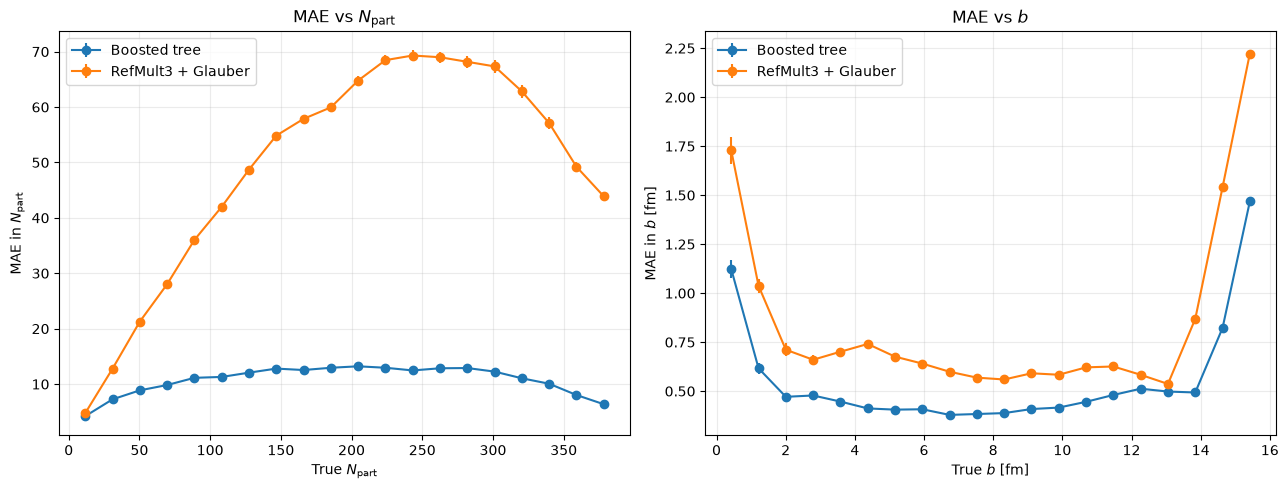

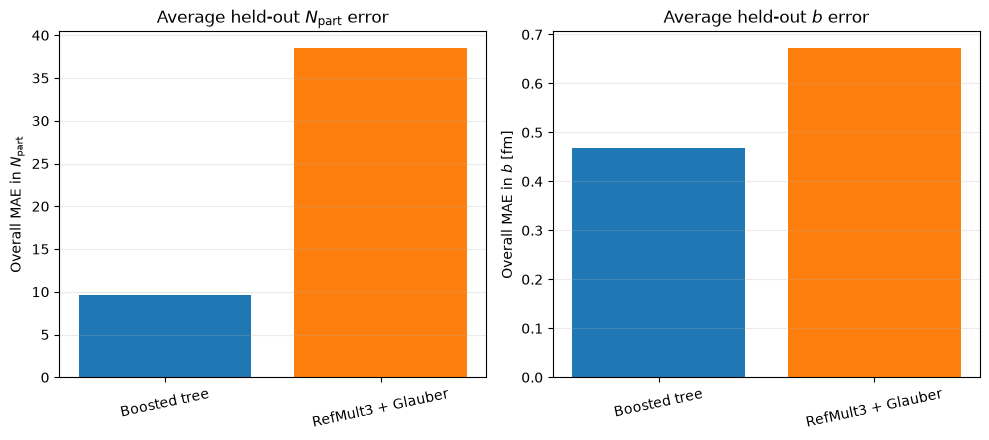

In [6]:
def regression_metrics(truth, prediction):
    return {
        "MAE": mean_absolute_error(truth, prediction),
        "RMSE": mean_squared_error(truth, prediction) ** 0.5,
        "R2": r2_score(truth, prediction),
    }


def binned_mae(truth, prediction, bins):
    truth = np.asarray(truth)
    error = np.abs(np.asarray(prediction) - truth)
    bin_index = np.digitize(truth, bins) - 1
    centers = 0.5 * (bins[:-1] + bins[1:])
    means = np.full(len(centers), np.nan)
    sems = np.full(len(centers), np.nan)
    counts = np.zeros(len(centers), dtype=int)
    for index in range(len(centers)):
        selected = bin_index == index
        counts[index] = selected.sum()
        if counts[index]:
            means[index] = error[selected].mean()
            sems[index] = error[selected].std(ddof=1) / np.sqrt(counts[index])
    return centers, means, sems, counts


test_npart = npart_selected[test_idx]
test_b = b_selected[test_idx]
metrics = {
    "Boosted tree Npart": regression_metrics(test_npart, npart_tree_pred),
    "RefMult3+Glauber Npart": regression_metrics(test_npart, npart_refmult3_pred),
    "Boosted tree b": regression_metrics(test_b, b_tree_pred),
    "RefMult3+Glauber b": regression_metrics(test_b, b_refmult3_pred),
}
for label, values in metrics.items():
    print(label + ": " + ", ".join(f"{key}={value:.4f}" for key, value in values.items()))

npart_bins = np.linspace(test_npart.min(), test_npart.max(), 21)
b_bins = np.linspace(test_b.min(), test_b.max(), 21)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for prediction, label in (
    (npart_tree_pred, "Boosted tree"),
    (npart_refmult3_pred, "RefMult3 + Glauber"),
):
    centers, means, sems, counts = binned_mae(test_npart, prediction, npart_bins)
    valid = counts >= 20
    axes[0].errorbar(centers[valid], means[valid], yerr=sems[valid], marker="o", label=label)
for prediction, label in (
    (b_tree_pred, "Boosted tree"),
    (b_refmult3_pred, "RefMult3 + Glauber"),
):
    centers, means, sems, counts = binned_mae(test_b, prediction, b_bins)
    valid = counts >= 20
    axes[1].errorbar(centers[valid], means[valid], yerr=sems[valid], marker="o", label=label)

axes[0].set(xlabel=r"True $N_{\mathrm{part}}$", ylabel=r"MAE in $N_{\mathrm{part}}$", title=r"MAE vs $N_{\mathrm{part}}$")
axes[1].set(xlabel=r"True $b$ [fm]", ylabel=r"MAE in $b$ [fm]", title=r"MAE vs $b$")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "mae_vs_npart_and_b.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
labels = ["Boosted tree", "RefMult3 + Glauber"]
npart_mae = [metrics["Boosted tree Npart"]["MAE"], metrics["RefMult3+Glauber Npart"]["MAE"]]
b_mae = [metrics["Boosted tree b"]["MAE"], metrics["RefMult3+Glauber b"]["MAE"]]
axes[0].bar(labels, npart_mae, color=["tab:blue", "tab:orange"])
axes[1].bar(labels, b_mae, color=["tab:blue", "tab:orange"])
axes[0].set(ylabel=r"Overall MAE in $N_{\mathrm{part}}$", title=r"Average held-out $N_{\mathrm{part}}$ error")
axes[1].set(ylabel=r"Overall MAE in $b$ [fm]", title=r"Average held-out $b$ error")
for ax in axes:
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=12)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "overall_mae.png", dpi=180, bbox_inches="tight")
plt.show()

## CBM-style centrality and impact-parameter precision

Following Kuttan *et al.*, centrality is assigned in 5% classes using the
RefMult3 ordering of the held-out minimum-bias events. The signed prediction
error is defined as $b_{\mathrm{true}}-b_{\mathrm{pred}}$. Relative precision
is $\sigma_{\mathrm{err}}/b_{\mathrm{true}}$, evaluated in true-$b$ bins.

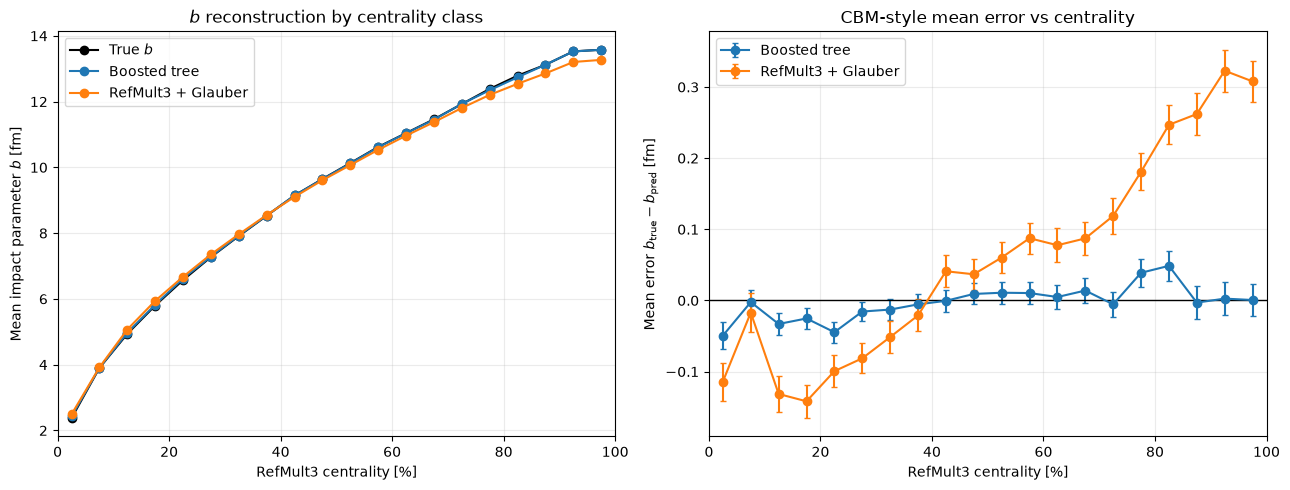

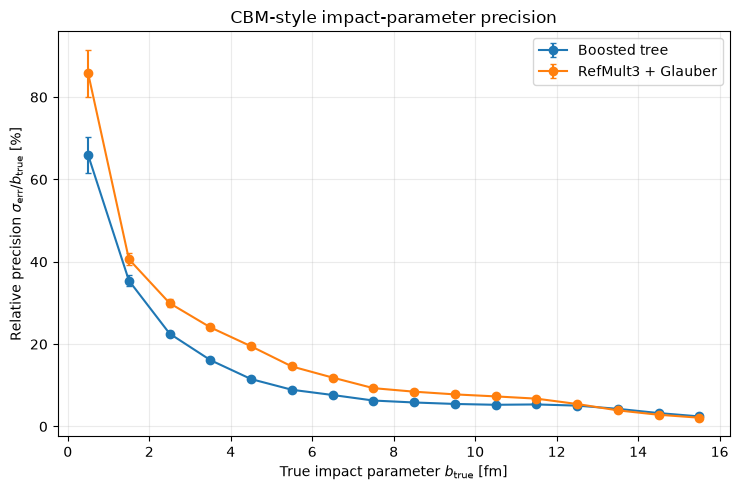

Boosted tree relative precision for 5 <= b <= 14 fm: 4.29% to 8.92%
RefMult3 + Glauber relative precision for 5 <= b <= 14 fm: 3.91% to 14.58%


In [7]:
# RefMult3 centrality: largest multiplicity is the most central event.
centrality_edges = np.arange(0.0, 100.0 + 5.0, 5.0)
centrality_centers = 0.5 * (centrality_edges[:-1] + centrality_edges[1:])
refmult_order = np.argsort(-test_refmult3, kind="stable")
event_centrality = np.empty(len(test_refmult3), dtype=float)
event_centrality[refmult_order] = (
    100.0 * (np.arange(len(test_refmult3)) + 0.5) / len(test_refmult3)
)
centrality_index = np.digitize(event_centrality, centrality_edges) - 1

centrality_true_b = np.full(len(centrality_centers), np.nan)
centrality_counts = np.zeros(len(centrality_centers), dtype=int)
centrality_results = {}
for label, prediction in (
    ("Boosted tree", b_tree_pred),
    ("RefMult3 + Glauber", b_refmult3_pred),
):
    mean_prediction = np.full(len(centrality_centers), np.nan)
    mean_error = np.full(len(centrality_centers), np.nan)
    error_sem = np.full(len(centrality_centers), np.nan)
    error = test_b - prediction
    for index in range(len(centrality_centers)):
        selected = centrality_index == index
        count = selected.sum()
        centrality_counts[index] = count
        if count:
            centrality_true_b[index] = test_b[selected].mean()
            mean_prediction[index] = prediction[selected].mean()
            mean_error[index] = error[selected].mean()
            error_sem[index] = error[selected].std(ddof=1) / np.sqrt(count)
    centrality_results[label] = {
        "mean_prediction": mean_prediction,
        "mean_error": mean_error,
        "error_sem": error_sem,
    }

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(
    centrality_centers,
    centrality_true_b,
    color="black",
    marker="o",
    label=r"True $b$",
)
for label, color in (("Boosted tree", "tab:blue"), ("RefMult3 + Glauber", "tab:orange")):
    result = centrality_results[label]
    axes[0].plot(
        centrality_centers,
        result["mean_prediction"],
        color=color,
        marker="o",
        label=label,
    )
    axes[1].errorbar(
        centrality_centers,
        result["mean_error"],
        yerr=result["error_sem"],
        color=color,
        marker="o",
        capsize=2,
        label=label,
    )
axes[0].set(
    xlabel="RefMult3 centrality [%]",
    ylabel=r"Mean impact parameter $b$ [fm]",
    title=r"$b$ reconstruction by centrality class",
)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set(
    xlabel="RefMult3 centrality [%]",
    ylabel=r"Mean error $b_{\mathrm{true}}-b_{\mathrm{pred}}$ [fm]",
    title="CBM-style mean error vs centrality",
)
for ax in axes:
    ax.set_xlim(0, 100)
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
fig.savefig(
    RESULTS_DIR / "centrality_refmult_vs_boosted_tree.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


# CBM definition: relative precision = std(true - predicted) / b_true.
b_precision_edges = np.arange(0.0, np.ceil(test_b.max()) + 1.0, 1.0)
b_precision_centers = 0.5 * (b_precision_edges[:-1] + b_precision_edges[1:])
b_precision_index = np.digitize(test_b, b_precision_edges) - 1
b_precision_results = {}

fig, ax = plt.subplots(figsize=(7.5, 5))
for label, prediction, color in (
    ("Boosted tree", b_tree_pred, "tab:blue"),
    ("RefMult3 + Glauber", b_refmult3_pred, "tab:orange"),
):
    relative_precision = np.full(len(b_precision_centers), np.nan)
    relative_precision_uncertainty = np.full(len(b_precision_centers), np.nan)
    counts = np.zeros(len(b_precision_centers), dtype=int)
    error = test_b - prediction
    for index in range(len(b_precision_centers)):
        selected = b_precision_index == index
        counts[index] = selected.sum()
        if counts[index] >= 20:
            b_true_bin = test_b[selected].mean()
            sigma_error = error[selected].std(ddof=1)
            relative_precision[index] = sigma_error / b_true_bin
            relative_precision_uncertainty[index] = (
                relative_precision[index] / np.sqrt(2.0 * (counts[index] - 1))
            )
    valid = counts >= 20
    ax.errorbar(
        b_precision_centers[valid],
        100.0 * relative_precision[valid],
        yerr=100.0 * relative_precision_uncertainty[valid],
        marker="o",
        capsize=2,
        color=color,
        label=label,
    )
    b_precision_results[label] = {
        "relative_precision": relative_precision,
        "uncertainty": relative_precision_uncertainty,
        "counts": counts,
    }

ax.set(
    xlabel=r"True impact parameter $b_{\mathrm{true}}$ [fm]",
    ylabel=r"Relative precision $\sigma_{\mathrm{err}}/b_{\mathrm{true}}$ [%]",
    title="CBM-style impact-parameter precision",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(
    RESULTS_DIR / "relative_b_precision_cbm.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

for label, result in b_precision_results.items():
    paper_range = (
        (b_precision_centers >= 5.0)
        & (b_precision_centers <= 14.0)
        & np.isfinite(result["relative_precision"])
    )
    values = 100.0 * result["relative_precision"][paper_range]
    print(
        f"{label} relative precision for 5 <= b <= 14 fm: "
        f"{values.min():.2f}% to {values.max():.2f}%"
    )

## Observable feature importance and saved results

Permutation importance is evaluated on a reproducible validation subset. The
saved archive contains held-out predictions, truth labels, split event IDs, and
the fitted NBD parameters.

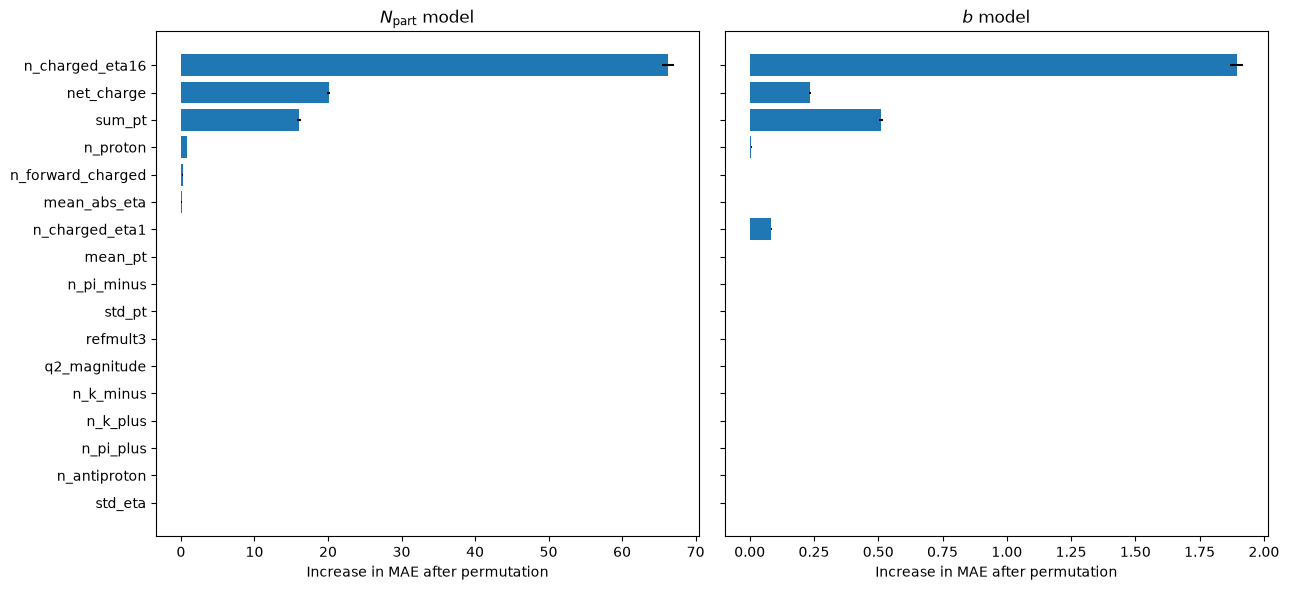

Saved results to /workspace/research/Deep_Learning_Npart/results/boosted_tree
No hidden information was included in X: refmult3, n_charged_eta1, n_charged_eta16, n_forward_charged, n_pi_plus, n_pi_minus, n_k_plus, n_k_minus, n_proton, n_antiproton, sum_pt, mean_pt, std_pt, mean_abs_eta, std_eta, net_charge, q2_magnitude


In [8]:
importance_idx = rng.choice(val_idx, size=min(5_000, len(val_idx)), replace=False)
importance_npart = permutation_importance(
    npart_model,
    X_selected[importance_idx],
    npart_selected[importance_idx],
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=SEED,
    n_jobs=-1,
)
importance_b = permutation_importance(
    b_model,
    X_selected[importance_idx],
    b_selected[importance_idx],
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=SEED,
    n_jobs=-1,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, importance, title in (
    (axes[0], importance_npart, r"$N_{\mathrm{part}}$ model"),
    (axes[1], importance_b, r"$b$ model"),
):
    order = np.argsort(importance.importances_mean)
    ax.barh(
        feature_names[order],
        importance.importances_mean[order],
        xerr=importance.importances_std[order],
    )
    ax.set(xlabel="Increase in MAE after permutation", title=title)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()

np.savez_compressed(
    RESULTS_DIR / "boosted_tree_results.npz",
    feature_names=feature_names,
    test_event_id=event_id_selected[test_idx],
    true_Npart=test_npart,
    true_b=test_b,
    refmult3=test_refmult3,
    boosted_tree_Npart=npart_tree_pred,
    boosted_tree_b=b_tree_pred,
    refmult3_glauber_Npart=npart_refmult3_pred,
    refmult3_glauber_b=b_refmult3_pred,
    nbd_alpha=fit.alpha,
    nbd_mu=fit.mu,
    nbd_k=fit.k,
    nbd_histogram_probability_mae=fit_statistics.probability_mae,
    nbd_histogram_count_mae=fit_statistics.count_mae,
    nbd_ks_distance=fit_statistics.ks_distance,
    nbd_poisson_deviance_per_ndf=fit_statistics.poisson_deviance_per_ndf,
    nbd_pearson_chi2_per_ndf=fit_statistics.pearson_chi2_per_ndf,
    centrality_centers=centrality_centers,
    centrality_mean_true_b=centrality_true_b,
    centrality_boosted_tree_mean_b=centrality_results["Boosted tree"]["mean_prediction"],
    centrality_refmult3_glauber_mean_b=centrality_results["RefMult3 + Glauber"]["mean_prediction"],
    centrality_boosted_tree_mean_error=centrality_results["Boosted tree"]["mean_error"],
    centrality_refmult3_glauber_mean_error=centrality_results["RefMult3 + Glauber"]["mean_error"],
    b_precision_centers=b_precision_centers,
    b_precision_boosted_tree=b_precision_results["Boosted tree"]["relative_precision"],
    b_precision_refmult3_glauber=b_precision_results["RefMult3 + Glauber"]["relative_precision"],
)

print("Saved results to", RESULTS_DIR)
print("No hidden information was included in X:", ", ".join(feature_names))